In [3]:
from datasets import load_from_disk 
import matplotlib.pyplot as plt
import numpy as np


In [4]:
dset = load_from_disk("/home/noedia/links/scratch/crl/experiments/lognormal_stacked")

Loading dataset from disk:   0%|          | 0/100 [00:00<?, ?it/s]

### Plotting a few power spectra and 2D Lognormal fields

In [5]:
dset = dset.with_format("numpy")
data = dset[:10]
pks = data["power_spectrum"]   
deltas = data["density_contrast"]
psis = data['cosmo_params']

# Should be 
print("Power spectrum data shape:", pks.shape) #(N_cosmo=5, num_points) 
print("Density fields data shape:", deltas.shape) #(N_cosmo=5, N_fields=10, img_size, img_size) 
print("Cosmo params data shape:", psis.shape) # (N_cosmo=5, 5) 

Power spectrum data shape: (10, 300)
Density fields data shape: (10, 10, 128, 128)
Cosmo params data shape: (10, 5)


Now, making sure that the data are different realizations: 

In [6]:
deltas.max()

98.76751

In [7]:
deltas[6, 2]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [8]:
from astro_peek.datasets import *
from astro_peek.utils import load_yaml

In [22]:
def str_to_float_cfg(cfg, keys = None):
    for key in keys:
        cfg[key] = float(cfg[key])
    return cfg

print("Loading configs and instantiating priors...")
cfg = load_yaml("../../astro_peek/datasets/cosmo_prior.yaml")
prior_cfg = cfg['priors']
pk_cfg = str_to_float_cfg(cfg["matter_pk"], keys = ["kmin", "kmax"])
delta_cfg = str_to_float_cfg(cfg["density_field"], keys = ["kmin", "kmax"])
prior = instantiate_prior(prior_cfg)

 
prior_sample = {key: psis[1][i] for i, key in enumerate(prior.keys())}
k, Pk = compute_pk(prior_sample, **pk_cfg)


Loading configs and instantiating priors...


In [23]:
Pk

array([2.70147771e+03, 2.77417363e+03, 2.84874146e+03, 2.92522245e+03,
       3.00365834e+03, 3.08409107e+03, 3.16656303e+03, 3.25111697e+03,
       3.33779560e+03, 3.42664199e+03, 3.51769933e+03, 3.61101063e+03,
       3.70661901e+03, 3.80456760e+03, 3.90489914e+03, 4.00765629e+03,
       4.11288142e+03, 4.22061587e+03, 4.33090063e+03, 4.44377607e+03,
       4.55928134e+03, 4.67745491e+03, 4.79833403e+03, 4.92195371e+03,
       5.04834775e+03, 5.17754836e+03, 5.30958534e+03, 5.44448688e+03,
       5.58227873e+03, 5.72298290e+03, 5.86661898e+03, 6.01320379e+03,
       6.16275061e+03, 6.31526981e+03, 6.47076791e+03, 6.62924592e+03,
       6.79070101e+03, 6.95512564e+03, 7.12250606e+03, 7.29282377e+03,
       7.46605474e+03, 7.64216796e+03, 7.82112681e+03, 8.00288808e+03,
       8.18740039e+03, 8.37460579e+03, 8.56443913e+03, 8.75682707e+03,
       8.95168895e+03, 9.14893562e+03, 9.34846785e+03, 9.55017809e+03,
       9.75395017e+03, 9.95965868e+03, 1.01671695e+04, 1.03763383e+04,
      

In [53]:
pk_cfg

{'kmin': 0.0005, 'kmax': 10.0}

In [55]:
k

array([5.00000000e-04, 5.16838337e-04, 5.34243732e-04, 5.52235284e-04,
       5.70832731e-04, 5.90056478e-04, 6.09927617e-04, 6.30467950e-04,
       6.51700013e-04, 6.73647102e-04, 6.96333295e-04, 7.19783484e-04,
       7.44023397e-04, 7.69079630e-04, 7.94979673e-04, 8.21751944e-04,
       8.49425815e-04, 8.78031651e-04, 9.07600836e-04, 9.38165812e-04,
       9.69760116e-04, 1.00241841e-03, 1.03617653e-03, 1.07107151e-03,
       1.10714163e-03, 1.14442648e-03, 1.18296695e-03, 1.22280534e-03,
       1.26398536e-03, 1.30655218e-03, 1.35055251e-03, 1.39603463e-03,
       1.44304843e-03, 1.49164550e-03, 1.54187916e-03, 1.59380452e-03,
       1.64747855e-03, 1.70296015e-03, 1.76031018e-03, 1.81959157e-03,
       1.88086936e-03, 1.94421079e-03, 2.00968534e-03, 2.07736485e-03,
       2.14732359e-03, 2.21963831e-03, 2.29438834e-03, 2.37165571e-03,
       2.45152518e-03, 2.53408439e-03, 2.61942392e-03, 2.70763741e-03,
       2.79882163e-03, 2.89307663e-03, 2.99050582e-03, 3.09121611e-03,
      

In [51]:
pk_cfg

{'kmin': 0.0005, 'kmax': 10.0}

/tmp/ipykernel_450469/3029892001.py:18: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.loglog()
/tmp/ipykernel_450469/3029892001.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set(xlim = [1e-4, 2e1])


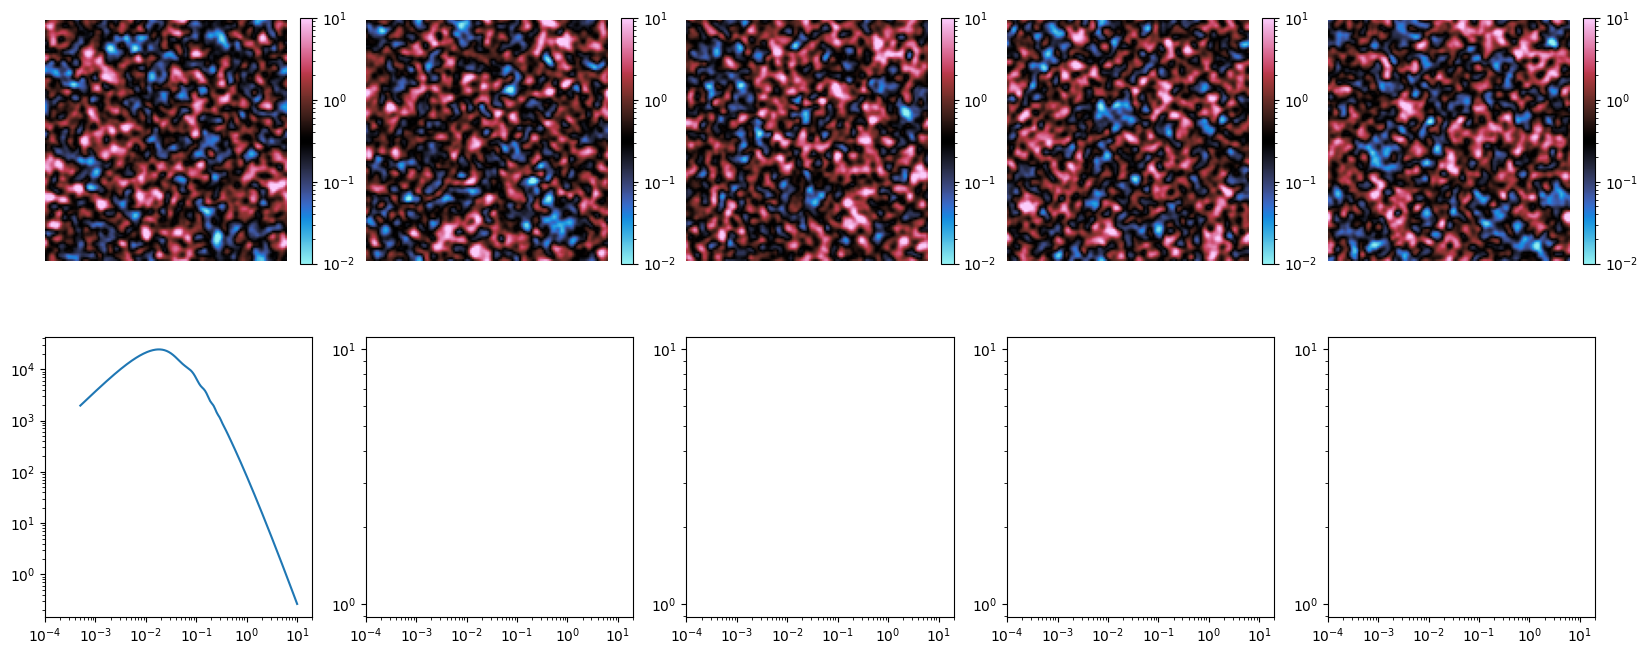

In [17]:
from cmap import Colormap
from matplotlib.colors import LogNorm

cmap = Colormap("cmasher:redshift").to_mpl()

fig, axs = plt.subplots(2, 5, figsize = (4 * 5, 4 * 2))

for i, row_ax in enumerate(axs): 

    if i == 0: 
        for j, ax in enumerate(row_ax):
            im = ax.imshow(1 + deltas[0, j], norm = LogNorm(vmin = 1e-2, vmax = 1e1, clip = True), cmap = cmap)
            plt.colorbar(im, ax = ax, fraction = 0.046)
            ax.axis("off")
    else: 
        for j, ax in enumerate(row_ax):
            ax.plot(k, pks[j])
            ax.loglog()
            ax.set(xlim = [1e-4, 2e1])
        

Running the script from here to check what the hell is wrong 

In [26]:
!/home/noedia/causal_env/bin/python /home/noedia/links/projects/rrg-lplevass/noedia/classes/crl/astro-ml-peek/astro_peek/datasets/make_lognormal.py --num_cosmo=4 --num_fields_per_cosmo=2 --output_dir=/home/noedia/links/scratch/crl/experiments/lognormal/data/test

Loading configs and instantiating priors...
Running main loop to create LogNormal fields.
100%|█████████████████████████████████████████████| 4/4 [00:33<00:00,  8.36s/it]
Saving everything to disk...
Saving the dataset (1/1 shards): 100%|████| 4/4 [00:00<00:00, 243.89 examples/s]


In [10]:
from datasets import load_from_disk
import os 
from tqdm import tqdm 

# Concatenating the LogNormal dsets chunks into one big dataset: 
base_dir = "/home/noedia/links/scratch/crl/experiments/lognormal_bis_2/"
paths = os.listdir(base_dir)
dsets = []
for path in tqdm(paths): 
    dset_dir = base_dir + path
    dsets.append(load_from_disk(dset_dir))



100%|██████████| 50/50 [00:00<00:00, 441.30it/s]


In [7]:
len(paths)

50

In [11]:
from datasets import concatenate_datasets

dset = concatenate_datasets(dsets)

In [12]:
dset.save_to_disk("/home/noedia/links/scratch/crl/experiments/lognormal/data/lognormal_images", num_shards = 100)

Saving the dataset (0/100 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

In [1]:
from datasets import load_from_disk 
import numpy as np 
dset = load_from_disk("/home/noedia/links/scratch/crl/experiments/lognormal/data/lognormal_images")

Loading dataset from disk:   0%|          | 0/100 [00:00<?, ?it/s]

In [6]:
len(dset)

1000

In [2]:
dset = dset.with_format("numpy")
data = dset[:5]
pks = data["power_spectrum"]  
ks = data["k_bins"]
deltas = data["density_contrast"]
psis = data['cosmo_params']

# Should be 
print("Power spectrum data shape:", pks.shape) #(N_cosmo=5, num_points) 
print("Density fields data shape:", deltas.shape) #(N_cosmo=5, N_fields=10, img_size, img_size) 
print("Cosmo params data shape:", psis.shape) # (N_cosmo=5, 5) 

Power spectrum data shape: (5, 300)
Density fields data shape: (5, 10, 128, 128)
Cosmo params data shape: (5, 5)


Visualizing the dataset

Text(0.5, 0.98, 'Varying cosmological parameters')

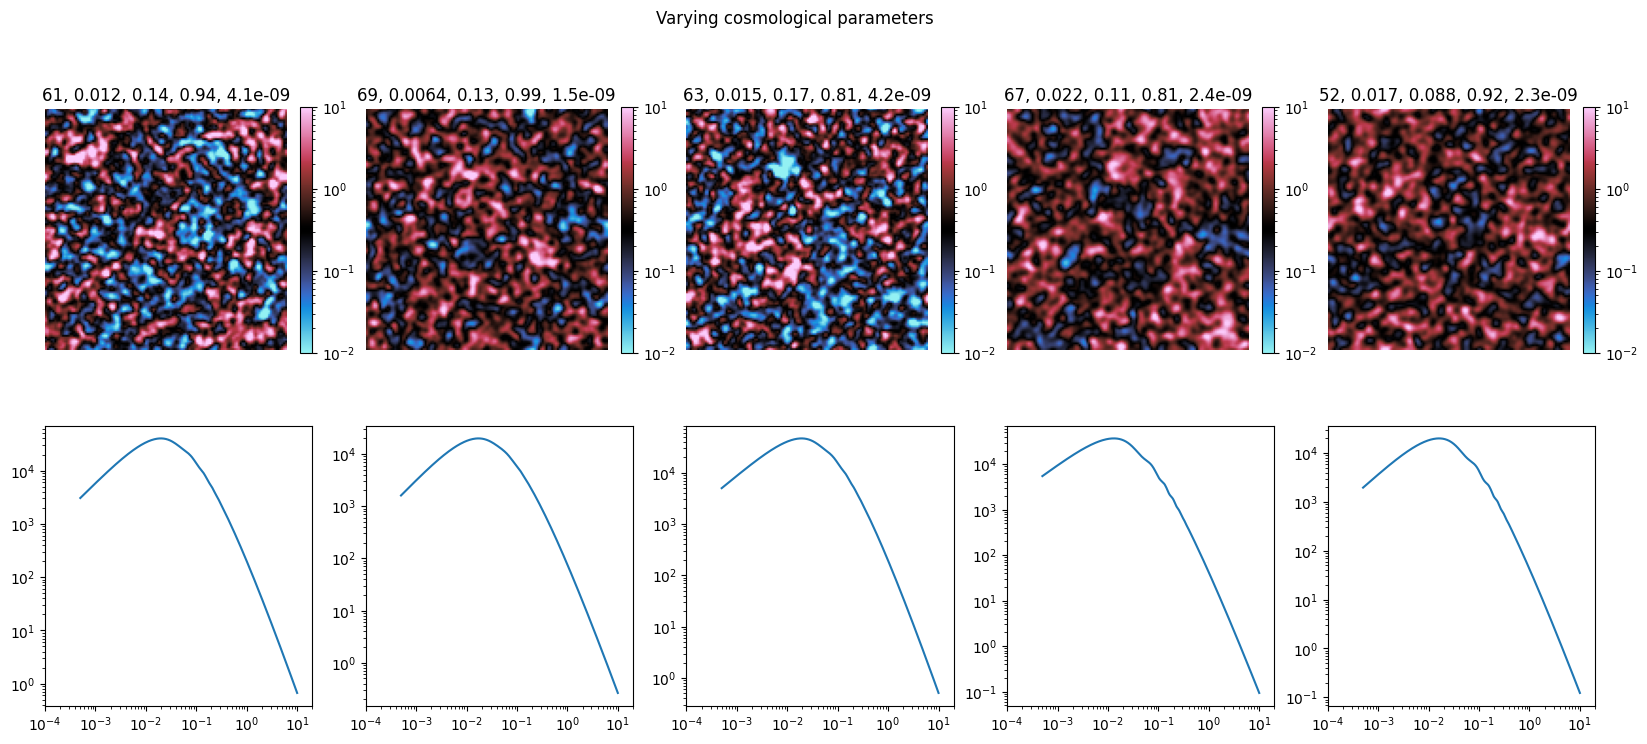

In [7]:
from cmap import Colormap
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

cmap = Colormap("cmasher:redshift").to_mpl()

fig, axs = plt.subplots(2, len(deltas), figsize = (4 * len(deltas), 4 * 2))

for i, row_ax in enumerate(axs): 

    if i == 0: 
        for j, ax in enumerate(row_ax):
            im = ax.imshow(1 + deltas[j, 0], norm = LogNorm(vmin = 1e-2, vmax = 1e1, clip = True), cmap = cmap)
            plt.colorbar(im, ax = ax, fraction = 0.046)
            ax.axis("off")
            title_str = ", ".join([f"{val:.2g}" for val in psis[j]])
            ax.set_title(title_str)
    else: 
        for j, ax in enumerate(row_ax):
            ax.plot(ks[j], pks[j])
            ax.loglog()
            ax.set(xlim = [1e-4, 2e1])

fig.suptitle("Varying cosmological parameters")

Text(0.5, 0.98, 'Fixed cosmological parameters')

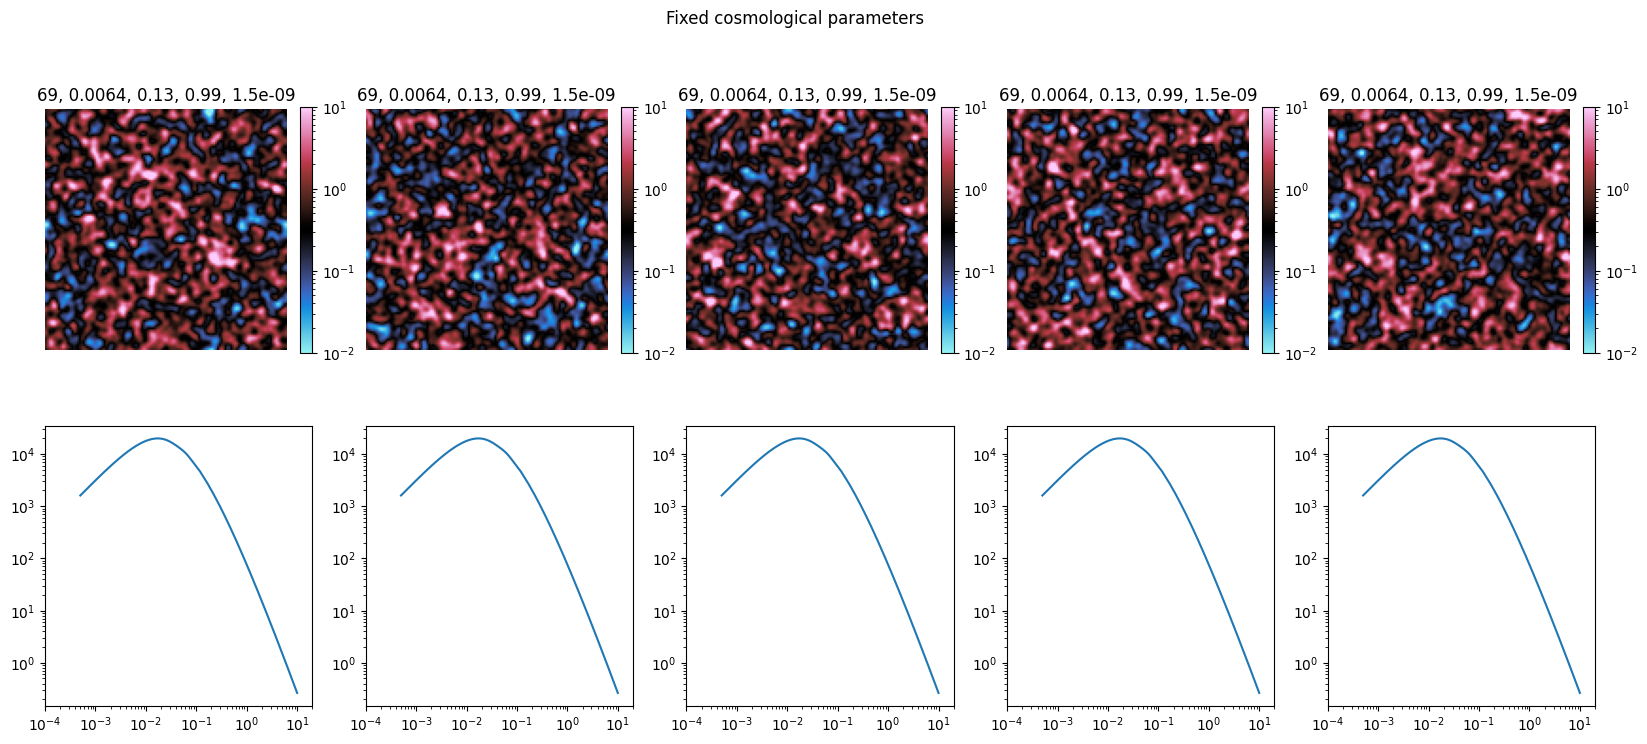

In [14]:
from cmap import Colormap
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

cmap = Colormap("cmasher:redshift").to_mpl()

fig, axs = plt.subplots(2, len(deltas), figsize = (4 * len(deltas), 4 * 2))

cosmo_idx = 1
for i, row_ax in enumerate(axs): 

    if i == 0: 
        for j, ax in enumerate(row_ax):
            im = ax.imshow(1 + deltas[cosmo_idx, j], norm = LogNorm(vmin = 1e-2, vmax = 1e1, clip = True), cmap = cmap)
            plt.colorbar(im, ax = ax, fraction = 0.046)
            ax.axis("off")
            title_str = ", ".join([f"{val:.2g}" for val in psis[cosmo_idx]])
            ax.set_title(title_str)
    else: 
        for j, ax in enumerate(row_ax):
            ax.plot(ks[0], pks[cosmo_idx])
            ax.loglog()
            ax.set(xlim = [1e-4, 2e1])

fig.suptitle("Fixed cosmological parameters")

Processing the dataset for the training

In [17]:
deltas.shape

(5, 10, 128, 128)

In [34]:
pk_repeats = np.tile(pks[:, None], (1, 10, 1)) # (N_cosmo, N_fields, 300)
print(pk_repeats.shape)

(5, 10, 300)


In [33]:
(pk_repeats[:, 1] == pk_repeats[:, 5]).any()

True

Saving flat chunks 

In [13]:
from datasets import load_from_disk, Dataset
import numpy as np 
from tqdm import tqdm 
src_dset = load_from_disk("/home/noedia/links/scratch/crl/experiments/lognormal/data/lognormal_images")
src_dset  = src_dset.with_format("numpy")

Loading dataset from disk:   0%|          | 0/100 [00:00<?, ?it/s]

In [14]:
chunk_size = 20
num_loops = len(src_dset)//chunk_size
dsets = []
for i in tqdm(range(num_loops)):
    data = src_dset[chunk_size * i: chunk_size * (i+1)]
    print(data.keys())
    pks = data["power_spectrum"]  
    ks = data["k_bins"]
    deltas = data["density_contrast"]
    psis = data['cosmo_params']

    # Flattening everything + tiling 
    pk_repeats = np.tile(pks[:, None], (1, 10, 1)) # (N_cosmo, N_fields, 300)
    psis_repeats = np.tile(psis[:, None], (1, 10, 1)) # (N_cosmo, N_fields, 300)

    
    pk_repeats_flat = pk_repeats.reshape((-1, pk_repeats.shape[-1]))
    deltas_flat = deltas.reshape((-1, deltas.shape[-2], deltas.shape[-1]))
    psis_flat = psis_repeats.reshape((-1, psis.shape[-1]))

    dset=Dataset.from_dict({
        "image": np.log10(1 + deltas_flat), # normalizing 
        "theta": np.log10(pk_repeats_flat),
        "cosmo_params": psis_flat
    })
    dsets.append(dset)

# # Should be 
# print("Power spectrum data shape:", pks.shape) #(N_cosmo=5, num_points) 
# print("Density fields data shape:", deltas.shape) #(N_cosmo=5, N_fields=10, img_size, img_size) 
# print("Cosmo params data shape:", psis.shape) # (N_cosmo=5, 5) 

  2%|▏         | 1/50 [00:00<00:09,  5.01it/s]

dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])
dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])


  8%|▊         | 4/50 [00:00<00:07,  6.25it/s]

dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])
dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])


 12%|█▏        | 6/50 [00:00<00:06,  6.40it/s]

...

dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])
dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])


 98%|█████████▊| 49/50 [00:07<00:00,  6.48it/s]

dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])
dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])


100%|██████████| 50/50 [00:07<00:00,  6.38it/s]

dict_keys(['power_spectrum', 'density_contrast', 'k_bins', 'cosmo_params'])


In [55]:
len(src_dset)

1000

In [33]:
from datasets import concatenate_datasets
tgt_dset = concatenate_datasets(dsets)
tgt_dset = tgt_dset.shuffle(seed = 42)
tgt_dset = tgt_dset.train_test_split(train_size = 0.8, test_size=0.2)

In [34]:
tgt_dset.save_to_disk("/home/noedia/links/scratch/crl/experiments/lognormal/data/lognormal-flat", num_shards={"train": 80, "test": 20})

Saving the dataset (0/80 shards):   0%|          | 0/8000 [00:00<?, ? examples/s]

Saving the dataset (0/20 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

In [18]:
dset = tgt_dset
dset = dset.with_format("numpy")
data = dset[:5]
pks = data["theta"]  
deltas = data["image"]
psis = data['cosmo_params']

# Should be 
print("Power spectrum data shape:", pks.shape) #(N_cosmo=5, num_points) 
print("Density fields data shape:", deltas.shape) #(N_cosmo=5, N_fields=10, img_size, img_size) 
print("Cosmo params data shape:", psis.shape) # (N_cosmo=5, 5) 

Power spectrum data shape: (5, 300)
Density fields data shape: (5, 128, 128)
Cosmo params data shape: (5, 5)


Text(0.5, 0.98, 'Varying cosmological parameters')

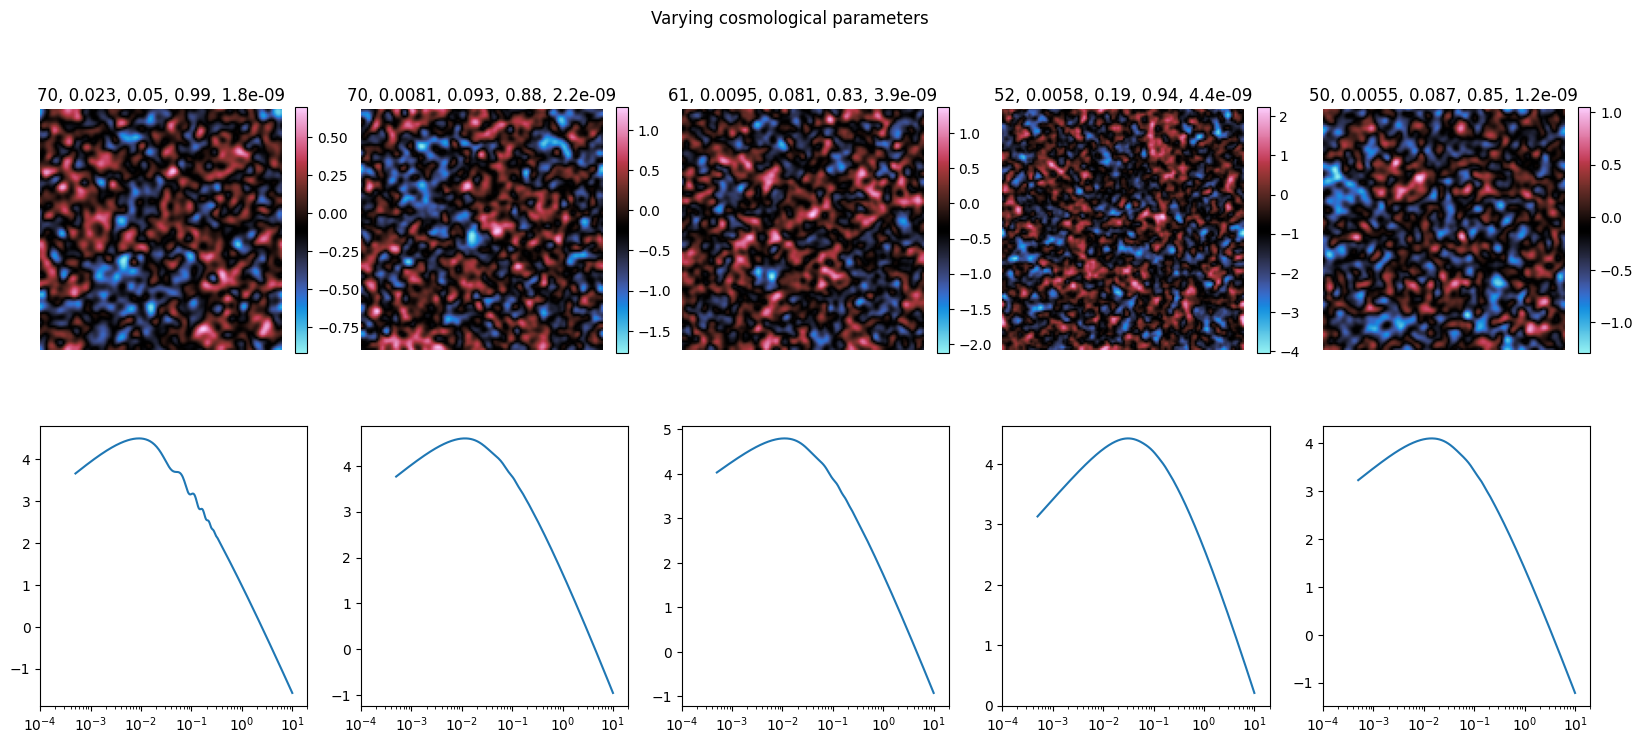

In [27]:
from cmap import Colormap
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

cmap = Colormap("cmasher:redshift").to_mpl()

fig, axs = plt.subplots(2, len(deltas), figsize = (4 * len(deltas), 4 * 2))

for i, row_ax in enumerate(axs): 

    if i == 0: 
        for j, ax in enumerate(row_ax):
            im = ax.imshow(deltas[j], norm = None, cmap = cmap)
            plt.colorbar(im, ax = ax, fraction = 0.046)
            ax.axis("off")
            title_str = ", ".join([f"{val:.2g}" for val in psis[j]])
            ax.set_title(title_str)
    else: 
        for j, ax in enumerate(row_ax):
            ax.plot(ks[j], pks[j])
            # ax.loglog()
            ax.set_xscale("log")
            ax.set(xlim = [1e-4, 2e1])

fig.suptitle("Varying cosmological parameters")

In [38]:
pk_repeats_flat.shape

(50, 300)

In [16]:
pks.shape

(5, 300)